In [8]:
from pandas import read_csv
import time
from matplotlib import pyplot as plt
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [9]:
# Load dataset
dataset = pd.read_csv("Salary_Data.csv")

# Remove missing values
dataset = dataset.dropna()

# Convert categorical columns to numeric
dataset["Gender"] = dataset["Gender"].astype("category").cat.codes
dataset["Education Level"] = dataset["Education Level"].astype("category").cat.codes
dataset["Job Title"] = dataset["Job Title"].astype("category").cat.codes

# Features
X = dataset.drop("Salary", axis=1)

# Target
y = dataset["Salary"]

# Split the dataset into training and validation sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=1
)

print(dataset.head())

    Age  Gender  Education Level  Job Title  Years of Experience    Salary
0  32.0       1                0        175                  5.0   90000.0
1  28.0       0                3         18                  3.0   65000.0
2  45.0       1                5        144                 15.0  150000.0
3  36.0       0                0        115                  7.0   60000.0
4  52.0       1                3         25                 20.0  200000.0


In [10]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import LinearRegression

cv = KFold(n_splits=10, random_state=1, shuffle=True)

model_LR = LinearRegression()

scores = cross_val_score(
    model_LR,
    X_train,
    y_train,
    scoring='r2',
    cv=cv
)

print("R2 Score: %.3f (%.3f)" % (scores.mean(), scores.std()))

R2 Score: 0.664 (0.017)


In [11]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.neighbors import KNeighborsRegressor

# Create model
model_KNN = KNeighborsRegressor(n_neighbors=3)

# Prepare the cross-validation procedure
cv = KFold(n_splits=10, random_state=1, shuffle=True)

# Evaluate model using cross-validation
scores = cross_val_score(
    model_KNN,
    X_train,
    y_train,
    scoring='r2',
    cv=cv
)

# Report performance
print('R2 Score: %.3f (%.3f)' % (scores.mean(), scores.std()))

R2 Score: 0.969 (0.007)


In [12]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.tree import DecisionTreeRegressor
from numpy import mean, std

# Create model
model_DT = DecisionTreeRegressor(random_state=1)

# Prepare the cross-validation procedure
cv = KFold(n_splits=10, random_state=1, shuffle=True)

# Evaluate model
scores = cross_val_score(
    model_DT,
    X_train,
    y_train,
    scoring='r2',
    cv=cv
)

# Report performance
print('R2 Score: %.3f (%.3f)' % (mean(scores), std(scores)))

R2 Score: 0.962 (0.017)


In [13]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.svm import SVR
from numpy import mean, std

# Prepare the cross-validation procedure
cv = KFold(n_splits=10, random_state=1, shuffle=True)

# Create model
model_SVM = SVR()

# Evaluate model
scores = cross_val_score(
    model_SVM,
    X_train,
    y_train,
    scoring='r2',
    cv=cv
)

# Report performance
print('R2 Score: %.3f (%.3f)' % (mean(scores), std(scores)))

R2 Score: -0.004 (0.009)


In [14]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import RandomForestRegressor
from numpy import mean, std

# Prepare the cross-validation procedure
cv = KFold(n_splits=10, random_state=1, shuffle=True)

# Create model
model_RF = RandomForestRegressor(random_state=1)

# Evaluate model
scores = cross_val_score(
    model_RF,
    X_train,
    y_train,
    scoring='r2',
    cv=cv
)

# Report performance
print('R2 Score: %.3f (%.3f)' % (mean(scores), std(scores)))

R2 Score: 0.976 (0.005)


In [15]:
# Spot Check Algorithms
models = []

models.append(('LR', LinearRegression()))
models.append(('KNN', KNeighborsRegressor()))
models.append(('CART', DecisionTreeRegressor(random_state=1)))
models.append(('SVR', SVR()))
models.append(('RF', RandomForestRegressor(random_state=1)))

# Evaluate each model in turn
results = []
names = []

for name, model in models:

    kfold = KFold(n_splits=10, random_state=1, shuffle=True)

    cv_results = cross_val_score(
        model,
        X_train,
        y_train,
        cv=kfold,
        scoring='r2'
    )

    results.append(cv_results)
    names.append(name)

    print('%s: %f (%f)' % (name, cv_results.mean(), cv_results.std()))

LR: 0.663993 (0.017140)
KNN: 0.965227 (0.005723)
CART: 0.962281 (0.016806)
SVR: -0.003626 (0.009436)
RF: 0.975703 (0.004769)


/tmp/ipykernel_5229/102339465.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(results, labels=names)


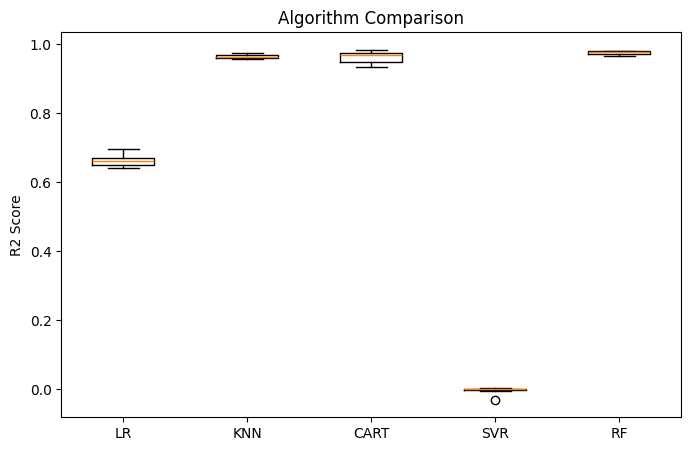

In [17]:


plt.figure(figsize=(8,5))

plt.boxplot(results, labels=names)

plt.title('Algorithm Comparison')

plt.ylabel('R2 Score')

plt.show()

In [18]:
best_model = RandomForestRegressor(random_state=1)

best_model.fit(X_train, y_train)

predictions = best_model.predict(X_test)

In [19]:
print("Mean Absolute Error :", mean_absolute_error(y_test, predictions))

print("Mean Squared Error  :", mean_squared_error(y_test, predictions))

print("R2 Score            :", r2_score(y_test, predictions))

Mean Absolute Error : 2785.3298700849814
Mean Squared Error  : 58752957.61442089
R2 Score            : 0.9789823169429253


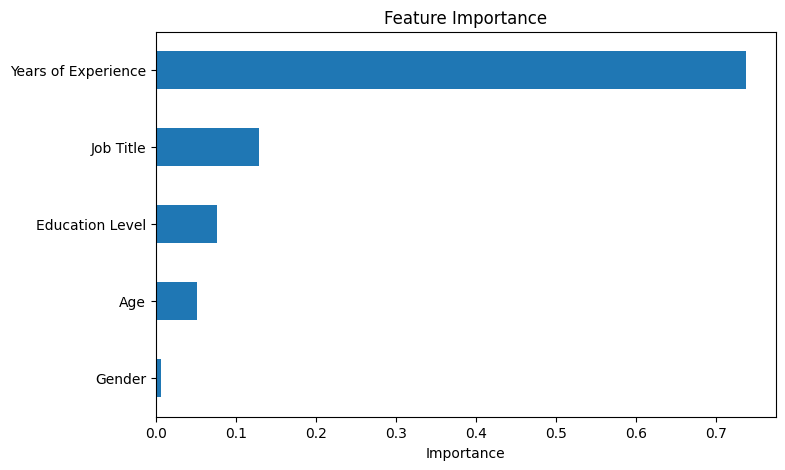

In [20]:
importance = pd.Series(
    best_model.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(
    kind='barh',
    figsize=(8,5)
)

plt.title("Feature Importance")

plt.xlabel("Importance")

plt.show()